# 09 · 고정 sparsity 대신 전역 importance 하한으로 예산 배분

## 문제

3개 실제 projection layer의 activation을 새 forward로 수집한다. 층 $j$의 importance는 $\sum_i v_{ji}=1$로 정규화한다. 동일 가중치 $w_j=1/3$로 평균 보존율을 정의한다. 이 가중치는 명시적 실험 선택이며 모델 loss로부터 유도된 상수는 아니다.

$$\min_{M_1,M_2,M_3}\sum_jL_j(M_j)
\quad\text{s.t.}\quad\sum_jw_jI_j(M_j)\ge q.$$

모든 층에서 $|M_j|/n_j=r$을 고정하는 전략은 위 문제의 작은 부분집합만 탐색한다. 같은 importance 하한에서 층마다 선택률을 다르게 배분할 여지가 있는지 확인한다.

## finite candidate 문제의 정확해

방법 $A$가 층 $j$에서 생성한 후보 집합을 $\mathcal C_{j,A}$라 두자. $r\in\{0,.15,.3,.45,.6,.75,.9,1\}$마다 새 mask를 만든다. 이산 문제는

$$L_A^{grid}(q)=\min_{(M_j)\in\prod_j\mathcal C_{j,A}}
\left\{\sum_jL_j(M_j):\sum_jw_jI_j(M_j)\ge q\right\}.$$

3층 × 8후보라 $8^3=512$개 조합을 전부 계산한다. 이 범위에서는 전역 정확해다. **모든 channel mask를 포함하는 원래 문제의 global optimum은 아니다.** 이 큰 채널 실험의 paper baseline은 minimum/step 1 row, stride cap 4 rows로 명시적으로 설정한다. 작은 oracle 실험의 stride cap 1과 구분한다. 같은 grid에서 fixed-$r$ 조합이 포함되므로

$$L_A^{grid}(q)\le L_A^{fixed-grid}(q).$$

이 관계는 실험으로 기대하는 경험 법칙이 아니라 feasible set 포함관계의 정리다. 구현에서 매 target에 대해 검증한다. 다른 방법끼리의 우열에는 이런 포함관계가 없다.

## 다항시간 구조와 남는 제약

전역 scalarized 문제는 층별로 분해된다.

$$\max_{M_1,\ldots,M_J}\sum_j[w_jI_j(M_j)-\lambda L_j(M_j)]
=\sum_j\max_{M_j}[w_jI_j(M_j)-\lambda L_j(M_j)].$$

실험 04의 DP로 각 층의 scalarized 정확해를 얻을 수 있다. 그러나 shared $\lambda$만 바꾸어 discrete coverage의 모든 optimum을 찾는다는 보장은 없다. unsupported point 문제가 층을 합친 공간에도 남는다.

후보 coverage를 $\delta$ 단위로 정수화해 $q_{jc}=\lfloor w_jI_j(M_{jc})/\delta\rfloor$로 두면

$$D_j[z]=\min_{c\in\mathcal C_j}\{D_{j-1}[z-q_{jc}]+L_j(M_{jc})\}$$

를 사용할 수 있다. $z\ge\lceil q/\delta\rceil$을 요구하면 실제 quality 하한을 보수적으로 만족한다. 복잡도 $O(JKZ)$는 quantization 정밀도에 의존하며 원래 실수 제약 문제의 강다항 해법이라고 할 수 없다. 노트북은 quantization 없이 작은 후보 곱집합을 직접 열거한다.

## 새 hardware 모델과 단위

이 노트북 안에서 SSD curve를 새로 측정한다. 원본 모델의 각 저장 행을 4 KiB page 배수로 padding한 가상 layout을 명시한다. 실제 저장된 모델 weight를 읽는 end-to-end benchmark는 아니다.

512 MiB 새 파일에서 측정한 최대 chunk $B=2048$ pages보다 긴 run은 외삽 대신 **명시적인 request 분할** 모델을 쓴다.

$$T_{split}(\ell)=\lfloor\ell/B\rfloor\hat T(B)+\hat T(\ell\bmod B),\qquad\hat T(0)=0.$$

이 역시 병렬 wall time이 아닌 가산 예측값이다. $s$를 row로 환산할 때 padding된 bytes/row를 사용한다. 나눠 읽는 정책과 가산 근사가 결과에 들어간다는 점을 숨기지 않는다.

## 출력과 결론의 범위

fixed/global candidate frontier, 같은 $q$의 비용 비교, layer별 실제 선택률 heatmap, 각 방법의 per-layer importance를 표시한다. 각 점이 만족한 평균 중요도와 **최소 층별 보존율**도 기록한다. 평균이 높아도 특정 층이 희생될 수 있다. 층별 quality 제약을 별도로 요구하면 새로운 문제다.

이 실험은 국소 가산 대리 목적의 전역 배분을 닫는다. 08에서 확인한 cross term과 실제 여러 층의 오차 전파를 없애지 않으며, 전역 task accuracy 최적화라는 결론으로 확대하지 않는다.


## 실행 설정과 provenance

Run All은 새로운 계산·측정을 수행하고 고유 run 디렉토리를 만듭니다.

In [1]:
from pathlib import Path
import json
import sys
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p / "conclusion_september" for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "conclusion_september/core.py").exists())
sys.path.insert(0, str(ROOT))
import core as C
from reporting import begin, figure, finish
SEED = 20260926
rng = np.random.default_rng(SEED)
RUN = begin(ROOT, "09_global_allocation", SEED)

**이번 실행:** `09_global_allocation-20260926T043828-d1a9d171` · seed `20260926` · 새 계산/측정

## 원본 activation과 새 SSD curve · 층별 후보 생성

In [2]:
from itertools import product
from capture import fresh_activations
from measure import profile, cost_table, near_saturation
layers = (3, 12, 21)
samples, model_meta = fresh_activations(layers=layers, seed=SEED)
(RUN / "model.json").write_text(json.dumps(model_meta, indent=2))
raw, hardware = profile(RUN, repeats=5, seed=SEED)
raw.to_csv(RUN / "io_raw.csv", index=False)
(RUN / "hardware.json").write_text(json.dumps(hardware, indent=2))
request_cap = int(raw.length.max())
page_cost = cost_table(raw, request_cap)
s_pages = near_saturation(raw)
fractions = np.array([0., .15, .3, .45, .6, .75, .9, 1.])
candidates, candidate_rows = {}, []
for layer in layers:
    X, W = samples[layer]
    v = np.abs(X).mean(0)
    v /= v.sum()
    n = len(v)
    pages_per_row = int(np.ceil(W.shape[1] * 4 / 4096))
    lengths = np.arange(n + 1) * pages_per_row
    cost = (lengths // request_cap) * page_cost[request_cap] + page_cost[lengths % request_cap]
    s = max(1, int(np.ceil(s_pages / pages_per_row)))
    for method in ["Top-R", "Paper", "Saturation"]:
        values = []
        for fraction in fractions:
            r = int(round(n * fraction))
            if method == "Top-R":
                mask = C.topk(v, r)
            elif method == "Paper":
                mask = C.paper(v, r, cost, s, jump=4)
            else:
                mask = C.saturation(v, r, cost, s)
            point = dict(layer=layer, method=method, nominal_fraction=float(fraction),
                         actual_fraction=float(mask.mean()), retained=float(v[mask].sum()),
                         latency=C.latency(mask, cost), pages_per_row=pages_per_row)
            values.append(point)
            candidate_rows.append(point)
        candidates[layer, method] = values
pd.DataFrame(candidate_rows).to_csv(RUN / "layer_candidates.csv", index=False)

## 전역해 · 각 방법의 유한 후보 곱집합을 완전탐색

In [3]:
records = []
for method in ["Top-R", "Paper", "Saturation"]:
    for indices in product(range(len(fractions)), repeat=len(layers)):
        points = [candidates[layer, method][index] for layer, index in zip(layers, indices)]
        row = dict(method=method, fixed=(len(set(indices)) == 1),
                   retained=np.mean([p["retained"] for p in points]),
                   minimum_layer_retained=min(p["retained"] for p in points),
                   latency=sum(p["latency"] for p in points))
        row.update({f"layer_{layer}_fraction": p["actual_fraction"] for layer, p in zip(layers, points)})
        records.append(row)
combinations = pd.DataFrame(records)
combinations.to_csv(RUN / "all_combinations.csv", index=False)
matched = []
for method, group in combinations.groupby("method"):
    for target in [.25, .5, .7, .8, .9, .95]:
        latencies = {}
        for mode in ["Fixed grid", "Global grid"]:
            feasible = group[(group.retained >= target-1e-12) & (group.fixed if mode == "Fixed grid" else True)]
            point = feasible.loc[feasible.latency.idxmin()]
            row = point.to_dict()
            row.update(mode=mode, target=target)
            matched.append(row)
            latencies[mode] = point.latency
        assert latencies["Global grid"] <= latencies["Fixed grid"] + 1e-10
comparison = pd.DataFrame(matched)
comparison.to_csv(RUN / "matched_global_quality.csv", index=False)
display(comparison[["method", "mode", "target", "retained", "minimum_layer_retained", "latency"]].round(4))

,method,mode,target,retained,minimum_layer_retained,latency
0,Paper,Fixed grid,0.25,0.3016,0.1617,0.7736
1,Paper,Global grid,0.25,0.3016,0.1617,0.7736
2,Paper,Fixed grid,0.50,0.5634,0.4751,2.2839
3,Paper,Global grid,0.50,0.5048,0.1646,1.7110
4,Paper,Fixed grid,0.70,0.8063,0.7638,3.6415
5,Paper,Global grid,0.70,0.7046,0.5787,2.6525
6,Paper,Fixed grid,0.80,0.8063,0.7638,3.6415
7,Paper,Global grid,0.80,0.8292,0.5787,3.2479
8,Paper,Fixed grid,0.90,0.9240,0.9087,4.3749
9,Paper,Global grid,0.90,0.9118,0.7353,3.8281


## 관측 · coverage와 실제 층별 선택률을 함께 보고

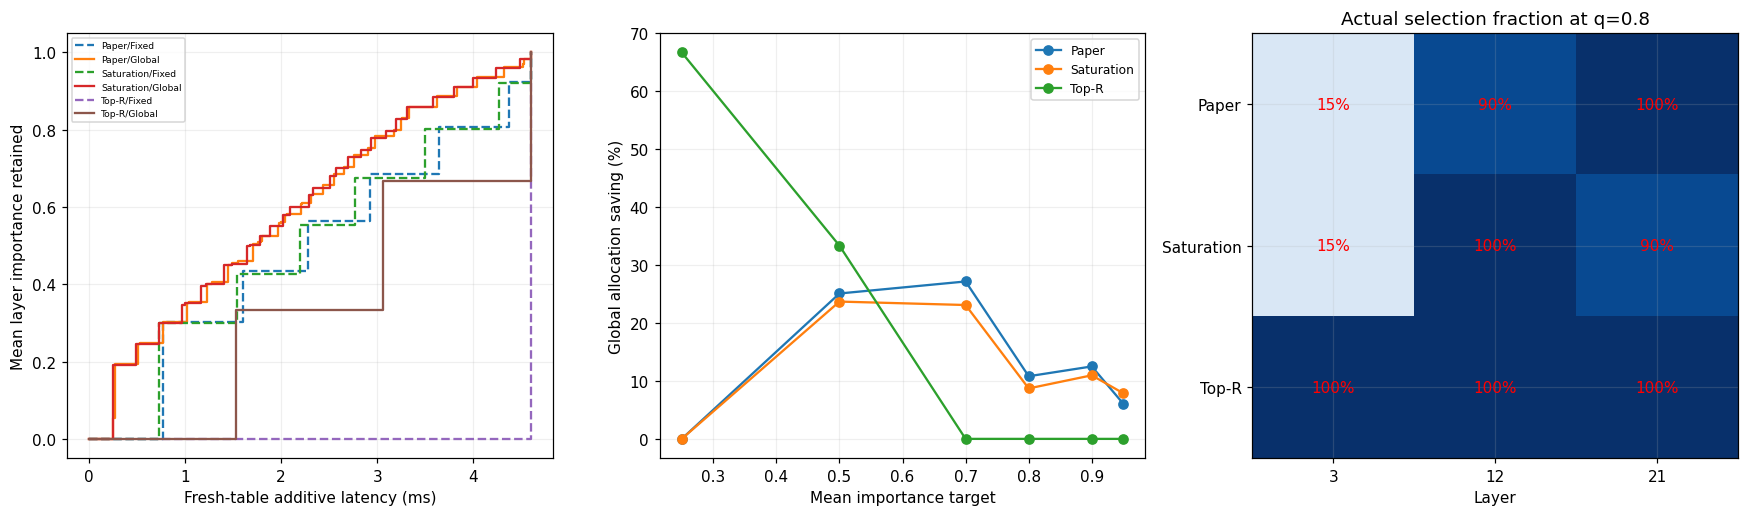

**실행에서 확인한 값**

- **fresh_layers**: [3, 12, 21]

- **combinations_per_method**: 512

- **inclusion_checks**: 18

- **near_best_pages**: 512

- **minimum_layer_retention_at_q80**: 0.5750036860568429

- **scope**: Exact within each finite candidate grid; padded-row additive I/O prediction, not global task accuracy

- **completed_utc**: 2026-09-26T04:38:42.310835+00:00

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for method, group in combinations.groupby("method"):
    for mode, subset, linestyle in [("Fixed", group[group.fixed], "--"), ("Global", group, "-")]:
        edge = subset.iloc[C.frontier(subset.retained.to_numpy(), subset.latency.to_numpy())]
        axes[0].step(edge.latency, edge.retained, where="post", ls=linestyle, label=f"{method}/{mode}")
axes[0].set(xlabel="Fresh-table additive latency (ms)", ylabel="Mean layer importance retained")
axes[0].legend(fontsize=6)
for method, group in comparison.groupby("method"):
    table = group.pivot(index="target", columns="mode", values="latency")
    axes[1].plot(table.index, 100*(1-table["Global grid"]/table["Fixed grid"]), "o-", label=method)
axes[1].set(xlabel="Mean importance target", ylabel="Global allocation saving (%)")
axes[1].legend(fontsize=8)
example = comparison[(comparison["mode"] == "Global grid") & (comparison.target == .8)]
values = example[[f"layer_{layer}_fraction" for layer in layers]].to_numpy()
axes[2].imshow(values, vmin=0, vmax=1, cmap="Blues", aspect="auto")
axes[2].set(xticks=range(len(layers)), xticklabels=layers, xlabel="Layer",
            yticks=range(len(example)), yticklabels=example.method, title="Actual selection fraction at q=0.8")
for row in range(len(example)):
    for col in range(len(layers)):
        axes[2].text(col, row, f"{values[row,col]:.0%}", ha="center", va="center", color="red")
figure(RUN, "global_allocation")
finish(RUN, fresh_layers=list(layers), combinations_per_method=len(fractions)**len(layers),
       inclusion_checks=18, near_best_pages=s_pages,
       minimum_layer_retention_at_q80=float(example.minimum_layer_retained.min()),
       scope="Exact within each finite candidate grid; padded-row additive I/O prediction, not global task accuracy")